# Miniproject 1 – Architecture 2: Overfitting CNN

**Team Members:** Aurel Köppel, Yves Fricker

**Course:** Applications of AI (AiAp), OST, Spring 2026

---

Same dataset and same split as notebook 1, but now with a much larger CNN. The goal is the opposite of before: we want the model to memorise the training set and fail on unseen data, so we can observe overfitting (high variance) cleanly.

## 1. Imports and Setup

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Set Keras backend to TensorFlow
os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
from keras import layers

# Import our shared helper functions
from helpers import (
    load_animals10,
    split_data,
    plot_learning_curves,
    plot_confusion_matrices,
    print_classification_metrics,
)

print(f"Keras version: {keras.__version__}")
print(f"Backend: {keras.backend.backend()}")

Keras version: 3.13.2
Backend: tensorflow


In [2]:
import kagglehub
import os

# Download dataset automatically (cached after first download)
path = kagglehub.dataset_download("alessiocorrado99/animals10")
DATA_DIR = os.path.join(path, "raw-img")

X, y, class_names = load_animals10(
    data_dir=DATA_DIR,
    img_size=64,
    samples_per_class=1000,
    reduced_class="elefante",
    reduced_count=150,
    seed=42,
)

X_trainval, X_test, y_trainval, y_test = split_data(X, y, test_size=0.3, random_state=42)

NUM_CLASSES = len(class_names)
IMG_SIZE = 64

print(f"\nClasses: {class_names}")
print(f"Train+Val: {X_trainval.shape}, Test: {X_test.shape}")

  Loaded 1000 images for class 'dog' (folder: cane)
  Loaded 1000 images for class 'horse' (folder: cavallo)
  Loaded 150 images for class 'elephant' (folder: elefante)
  Loaded 1000 images for class 'butterfly' (folder: farfalla)
  Loaded 1000 images for class 'chicken' (folder: gallina)
  Loaded 1000 images for class 'cat' (folder: gatto)
  Loaded 1000 images for class 'cow' (folder: mucca)
  Loaded 1000 images for class 'sheep' (folder: pecora)
  Loaded 1000 images for class 'spider' (folder: ragno)
  Loaded 1000 images for class 'squirrel' (folder: scoiattolo)

Total: 9150 images, 10 classes
Train+Val: 6405 samples
Test:      2745 samples (locked away)

Classes: ['dog', 'horse', 'elephant', 'butterfly', 'chicken', 'cat', 'cow', 'sheep', 'spider', 'squirrel']
Train+Val: (6405, 64, 64, 3), Test: (2745, 64, 64, 3)


## 3. Model Definition

We build a substantially larger network: four Conv2D blocks with 32, 64, 128 and 128 filters, each followed by MaxPooling. After flattening we add a `Dense(256)` hidden layer before the final softmax. That brings us to 767,946 trainable parameters, roughly 450× what we had in notebook 1.

With only about 6400 train+val samples and 770k parameters the model has enough capacity to essentially memorise the training set. There is no dropout, no weight decay, no data augmentation. Nothing stops it from overfitting.

| | Architecture 1 | Architecture 2 |
|---|---|---|
| Trainable layers | 3 | 6 |
| Parameters | ~1,700 | ~768,000 |
| Filters | 4, 8 | 32, 64, 128, 128 |
| Dense neurons | 0 (direct to output) | 256 |

In [3]:
model = keras.Sequential([
    keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    # Block 1: 32 filters — detects basic patterns (edges, textures)
    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),  # 64x64 -> 32x32

    # Block 2: 64 filters — combines basic patterns into more complex features
    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),  # 32x32 -> 16x16

    # Block 3: 128 filters — higher-level features (parts of animals)
    layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),  # 16x16 -> 8x8

    # Block 4: 128 filters — most abstract features
    layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),  # 8x8 -> 4x4

    # Classification head
    layers.Flatten(),          # 4 * 4 * 128 = 2048
    layers.Dense(256, activation="relu"),
    layers.Dense(NUM_CLASSES, activation="softmax"),
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 64, 64, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 32, 32, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 16, 16, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 8, 8, 128)           │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 4, 4, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         524,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 767,946 (2.93 MB)

 Trainable params: 767,946 (2.93 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
total_params = model.count_params()
print(f"\nTotal trainable parameters: {total_params:,}")
print(f"This is about {total_params / 1698:.0f}x more than Architecture 1.")


Total trainable parameters: 767,946
This is about 452x more than Architecture 1.


## 4. Compile and Train

Same optimiser (Adam), loss (`sparse_categorical_crossentropy`) and validation split (0.2) as in notebook 1. 50 epochs, batch size 32. Keeping the training hyperparameters identical makes the comparison against notebooks 1 and 3 cleaner.

In [5]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history = model.fit(
    X_trainval,
    y_trainval,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1,
)

Epoch 1/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.1940 - loss: 2.1386 - val_accuracy: 0.2849 - val_loss: 1.9888
Epoch 2/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.3353 - loss: 1.8379 - val_accuracy: 0.3333 - val_loss: 1.7694
Epoch 3/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.4132 - loss: 1.6416 - val_accuracy: 0.4192 - val_loss: 1.6350
Epoch 4/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.4899 - loss: 1.4632 - val_accuracy: 0.4723 - val_loss: 1.5284
Epoch 5/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.5529 - loss: 1.3058 - val_accuracy: 0.5059 - val_loss: 1.4336
Epoch 6/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.6056 - loss: 1.1317 - val_accuracy: 0.4996 - val_loss: 1.4944
Epoch 7/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.6380 - loss: 1.0419 - val_accuracy: 0.5059 - val_loss: 1.4688
Epoch 8/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.6903 - loss: 0.8938 - val_accu

## 5. Learning Curves

The typical overfitting pattern: training loss drops towards zero while the validation loss, after an initial drop, starts climbing again. Training accuracy approaches 100 % and validation accuracy stagnates. The widening gap between the two curves is what high variance looks like.

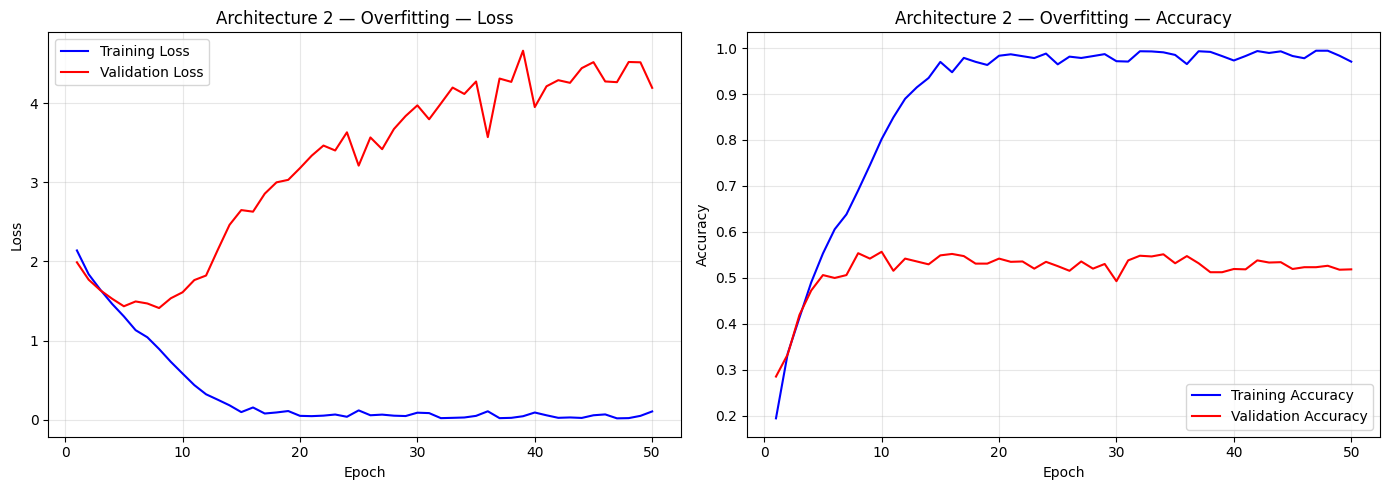

In [6]:
plot_learning_curves(history, title="Architecture 2 — Overfitting")

## 6. Confusion Matrices

In [7]:
# Extract validation set (same split as Keras uses)
val_split = int(len(X_trainval) * 0.8)
X_val = X_trainval[val_split:]
y_val = y_trainval[val_split:]

y_pred_probs = model.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1)

print(f"Validation set size: {len(X_val)}")

41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
Validation set size: 1281


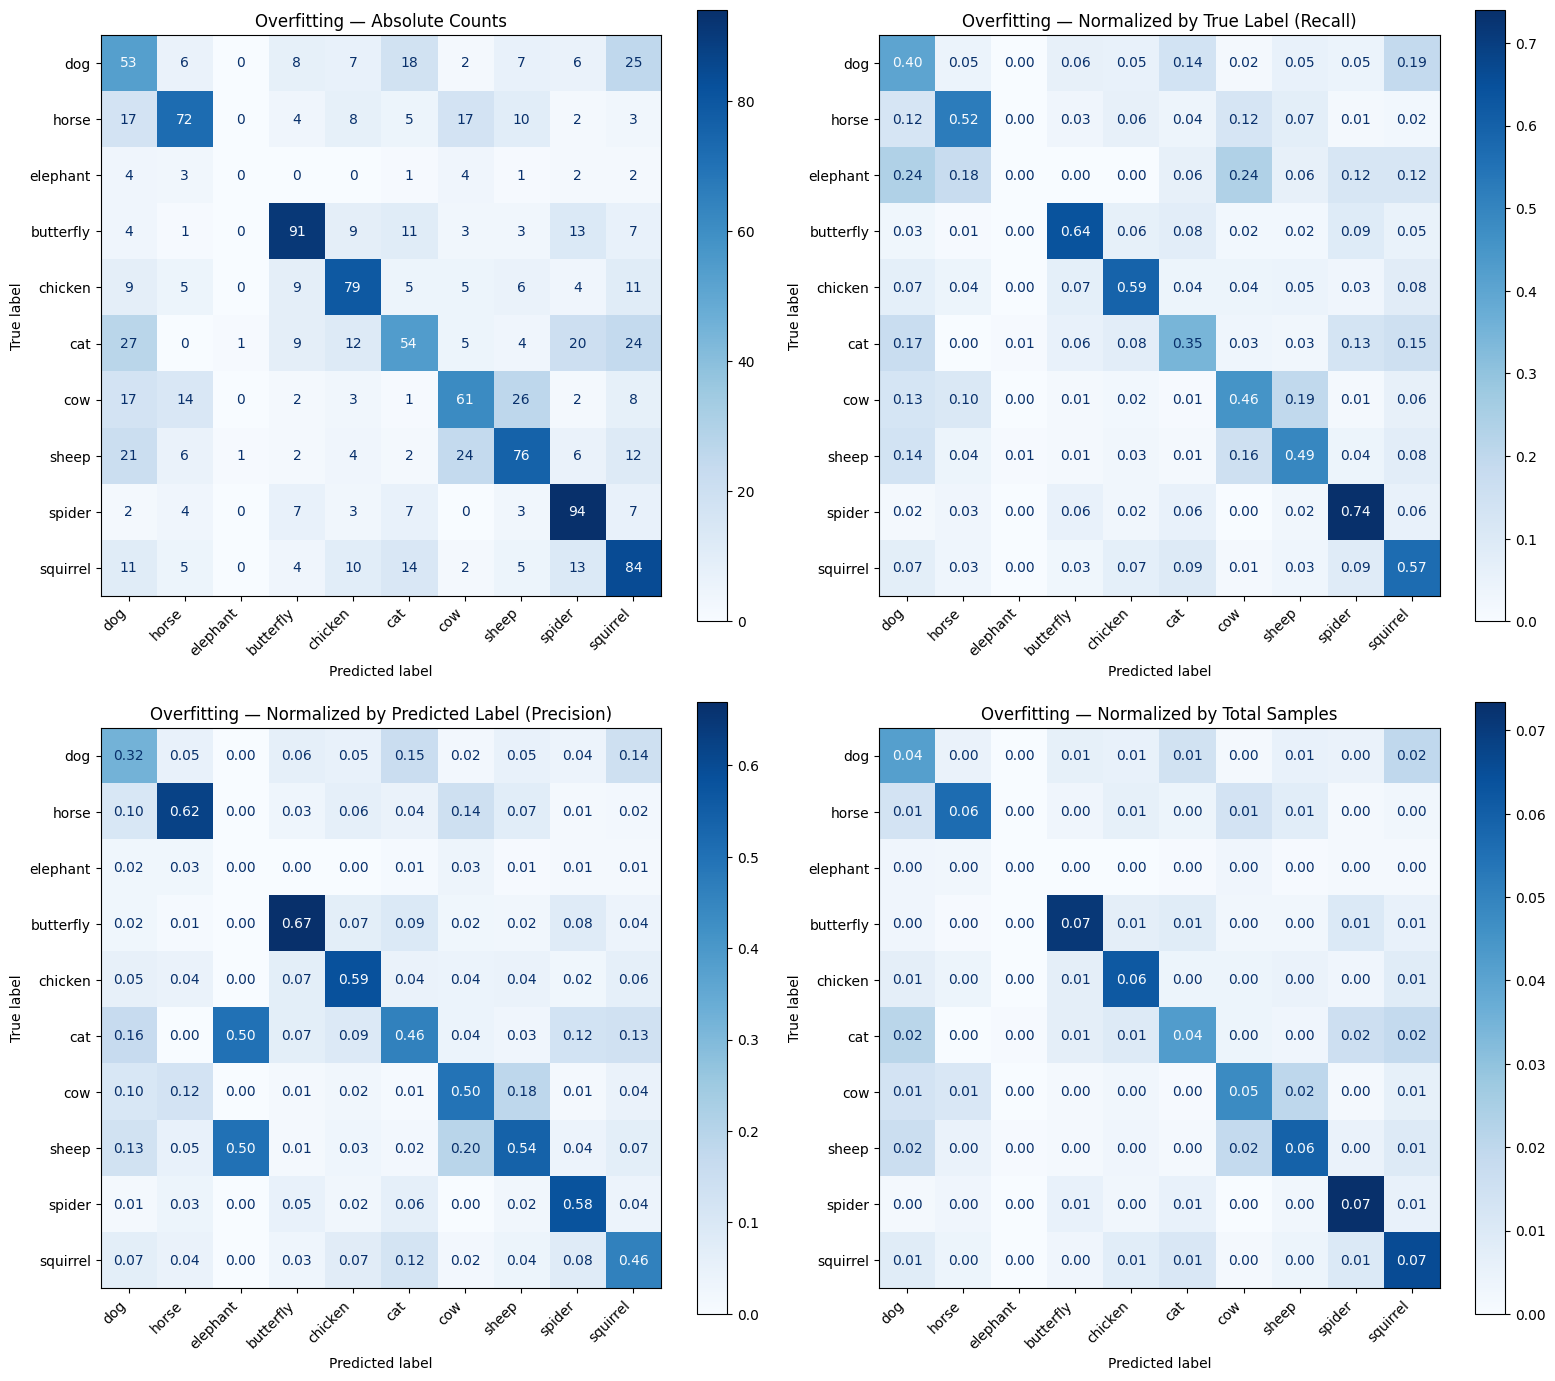

In [8]:
plot_confusion_matrices(y_val, y_pred, class_names, title_prefix="Overfitting — ")

### What the matrix shows

The diagonal is clearly stronger than in notebook 1, the model has learned useful features. The mammal block (dog, cat, cow, sheep, horse) still forms a cluster where classes get confused with each other, but the individual recalls are mostly in a comparable range now rather than a few classes collapsing entirely. Cat is the weakest mammal (recall around 35 %) and still gets partly absorbed into dog and sheep.

Butterfly, chicken and spider have the strongest diagonals. Their visual features (wing shapes, leg counts, body outlines) separate them from the mammal cluster well enough that the network can pick them up reliably. Elephant collapses to 0 recall and 0 precision, the same degenerate behaviour we saw in notebook 1. So the extra capacity of architecture 2 does not translate into any gain for the minority class, confirming that the problem is the sample count, not the model size.

## 7. Classification Metrics

In [9]:
print_classification_metrics(y_val, y_pred, class_names)

Classification Report:
              precision    recall  f1-score   support

         dog      0.321     0.402     0.357       132
       horse      0.621     0.522     0.567       138
    elephant      0.000     0.000     0.000        17
   butterfly      0.669     0.641     0.655       142
     chicken      0.585     0.594     0.590       133
         cat      0.458     0.346     0.394       156
         cow      0.496     0.455     0.475       134
       sheep      0.539     0.494     0.515       154
      spider      0.580     0.740     0.651       127
    squirrel      0.459     0.568     0.508       148

    accuracy                          0.518      1281
   macro avg      0.473     0.476     0.471      1281
weighted avg      0.518     0.518     0.514      1281



## 8. Discussion

The training loss collapses to almost zero within a few epochs and training accuracy reaches around 99 %. At the same time the validation loss bottoms out early and then starts climbing again, while validation accuracy plateaus around 52 %. That widening gap is the overfitting signature: the model has memorised specific training examples (including noise and individual quirks of single images) rather than extracting generalisable features.

Interestingly, the overfitted model still clearly outperforms architecture 1 on validation (around 52 % vs around 37 %). So the network does learn something useful, it just memorises on top of that. The filter progression 32 -> 64 -> 128 -> 128 follows the standard CNN idea of early layers detecting simple edges and textures and deeper layers combining them into class-specific parts.

Elephant remains the weakest class by a wide margin: precision and recall both collapse to 0, the model never predicts this class at all. Even with ~450x the capacity of architecture 1, more parameters do not compensate for only roughly 105 train+val samples, the imbalance is a data problem, not a capacity problem.

| Metric | Architecture 1 (Underfit) | Architecture 2 (Overfit) |
|---|---|---|
| Training Loss | High (cannot learn) | Very low (~0) |
| Validation Loss | High | Diverges |
| Train-Val Gap | Small (low variance) | Large (high variance) |
| Parameters | ~1,700 | ~768,000 |
| Problem | High bias | High variance |

In notebook 3 we keep this exact architecture (same layer count, same filter counts, same 767,946 parameters) and add regularisation. The goal is to keep the capacity of this model but suppress the memorisation.